# Info 

The following implementation studies the mechansim of attention for machine translation in transformers. This notebook implementation generates figures 5 and 6 in "In-Context Learning for Discrete Optimal Transport: Can
Transformers Sort?" by Hadi Daneshmand (contact: dhadi at virginia dot edu). Remarkably, generative AI is used for the implementation. We load a pretrained transformer "Helsinki-NLP/opus-mt-en-f" and check if attention heat map can approximately match translated words.  

In [1]:
#!pip install sentencepiece # installing required liberary 
#!pip install stanza
#!pip install --upgrade transformers
# stanza.download("fr")
# stanza.download("en")

In [1]:
# !pip install --upgrade transformers

In [8]:
# this plot loads data, dictionary and model implemented by assistance of GPT
import stanza
import os
nlp_en = stanza.Pipeline("en", processors="tokenize,pos,lemma")
nlp_fr = stanza.Pipeline("fr", processors="tokenize,pos,lemma")
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import re
import csv
import urllib.request
import numpy as np
import torch
from datasets import load_dataset
from transformers import MarianMTModel

try:
    from transformers import MarianTokenizerFast as MarianTok
except Exception:
    from transformers import MarianTokenizer as MarianTok


MODEL_NAME = "Helsinki-NLP/opus-mt-en-fr"  # MarianMT trained for english to french 
WMT_CONFIG = "fr-en"                        # provides {"en","fr"}
WMT_SPLIT = "train"
NUM_PAIRS = 22000
RANDOM_SEED = 42

# Dictionary (EN->FR) via MUSE
EN_FR_DICT_PATH = None  # if None, download MUSE (≈150k entries)
MIN_GOLD_PER_SENT = 1

# Length filter (simple word counts)
MIN_LEN = 8
MAX_EN_LEN = 80
MAX_FR_LEN = 80



# Decoder layers to evaluate (Marian base has 6 decoder layers)
EVAL_LAYERS = [1, 2, 3, 4, 5, 6]

OUT_DIR = "marian_crossattn_mrr_wmt14_1000"
os.makedirs(OUT_DIR, exist_ok=True)


def download_muse_en_fr(target_path="en_fr_muse.txt"): # loading dictionary 
    url = "https://dl.fbaipublicfiles.com/arrival/dictionaries/en-fr.txt"
    if not os.path.exists(target_path):
        print(f"Downloading EN-FR dictionary from {url} …")
        urllib.request.urlretrieve(url, target_path)
    return target_path

def load_en_fr_dictionary(path): # loading dictionary 
    """
    Loads either:
      - MUSE file 'en fr' (space-separated), or
      - TSV 'en\\tfr'
    Returns dict[str, set[str]] of lowercase word forms.
    """
    d = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: 
                continue
            if "\t" in line:
                en, fr = line.split("\t", 1)
            else:
                parts = line.split()
                if len(parts) < 2: 
                    continue
                en, fr = parts[0], parts[1]
            en = en.strip().lower(); fr = fr.strip().lower()
            if en and fr:
                d.setdefault(en, set()).add(fr)
    return d

if EN_FR_DICT_PATH is None:
    DICT_FILE = download_muse_en_fr()
else:
    DICT_FILE = EN_FR_DICT_PATH

EN2FR = load_en_fr_dictionary(DICT_FILE)
print(f"Loaded dictionary with {len(EN2FR)} English headwords")


tokenizer = MarianTok.from_pretrained(MODEL_NAME, use_fast=True)
model = MarianMTModel.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager",   # important for attention weights
).eval()


import stanza


def normalize(nlp, sentence):
    doc = nlp(sentence)
    lemmas = []

    for sent in doc.sentences:
        for word in sent.words:
            if word.lemma:
                lemmas.append(word.lemma.lower())
    return " ".join(lemmas)

# loading dataset (implemented by GPT) 
ds = load_dataset("wmt14", WMT_CONFIG, split=WMT_SPLIT)
ds = ds.shuffle(seed=RANDOM_SEED).select(range(min(NUM_PAIRS, len(ds))))







2026-03-31 17:58:16 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-03-31 17:58:16 INFO: Downloaded file to /u/xay7te/.cache/stanza/1.11.0/resources/resources.json
2026-03-31 17:58:16 WARNING: Language en package default expects mwt, which has been added
2026-03-31 17:58:16 INFO: Loading these models for language: en (English):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| pos       | combined_charlm   |
| lemma     | combined_nocharlm |

2026-03-31 17:58:16 INFO: Using device: cuda
2026-03-31 17:58:16 INFO: Loading: tokenize
2026-03-31 17:58:16 INFO: Loading: mwt
2026-03-31 17:58:16 INFO: Loading: pos
2026-03-31 17:58:17 INFO: Loading: lemma
2026-03-31 17:58:17 INFO: Done loading processors!
2026-03-31 17:58:17 INFO: Checking for updates to resou

Loaded dictionary with 94681 English headwords


Loading weights: 100%|█████████████████████| 258/258 [00:00<00:00, 69747.37it/s]
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [ ]:
#  reconsturcting the words attention across the layers for each setnence match translated words and
# measure how well attention weights can match translated words
# this code block is implemented without GenAI assistance 
from matplotlib import pyplot as plt
counter_sentence = 0
results = [] 
# helper functions implemented by Hadi Daneshmand 
def get_word_idx(token_ids): 
    tokens = tokenizer.convert_ids_to_tokens(token_ids)
    word_idx = -1
    widxs = []
    for i in range(len(tokens)):
        token = tokens[i]
        if token[0] == '▁':     
            word_idx +=1
        widxs.append(word_idx)
    return np.asarray(widxs)
def compute_dot(x,y): 
    x = torch.flatten(x) 
    # x = x/torch.norm(x)
    y = torch.flatten(y) 
    # y = y/torch.norm(y) 
    return torch.dot(x,y).item()
def get_words(tokenizer,tdict): 
    words = [] 
    tokens_ids = tdict['token_ids'] 
    nlp = tdict['nlp']
    word_ids = tdict['word_ids']
   
    for i in range(max(word_ids)): 
        
        idx_ids = np.where(word_ids == i)[0]
        # print(len(word_ids),i,idx_ids,len(tokens_ids))
        words.append(normalize(nlp,tokenizer.decode(tokens_ids[idx_ids])))
    return words
    
def compute_dot(x,y): 
    x = torch.flatten(x) 
    x = x/torch.norm(x)
    y = torch.flatten(y) 
    y = y/torch.norm(y) 
    return torch.dot(x,y).item()
for dataidx in range(len(ds)):
    ex = ds[dataidx] 
    en_text = normalize(nlp_en, ex["translation"]["en"])
    if len(en_text)<120: 
        continue
    fr_text = normalize(nlp_fr,ex["translation"]["fr"])
    if counter_sentence> 10000:
        break 
    # reconstructing tokens and extracting attentions 
    src = tokenizer([en_text], return_tensors="pt", padding=True,return_offsets_mapping=True)
    tgt = tokenizer([fr_text], return_tensors="pt", padding=True,return_offsets_mapping=True)
    if len(src['input_ids'][0])>511 or len(tgt['input_ids'][0])>511: 
        continue
    with torch.no_grad():
        decoder_input_ids = model.prepare_decoder_input_ids_from_labels(labels=tgt["input_ids"])
        out = model(
            input_ids=src["input_ids"], # english tokens 
            attention_mask=src["attention_mask"],
            decoder_input_ids=decoder_input_ids, # french tokens 
            decoder_attention_mask=tgt.get("attention_mask", None),
            output_attentions=True,
            use_cache=False,
            return_dict=True,
        )
    
    cross_atts = out.cross_attentions  
    fr_dict = {} 
    en_dict = {} 

    fr_dict['token_ids'] = np.asarray(tgt['input_ids'][0])
    en_dict['token_ids'] = np.asarray(src['input_ids'][0])
    fr_dict['nlp'] = nlp_fr 
    en_dict['nlp'] = nlp_en 
    en_dict['text'] = en_text 
    fr_dict['text'] = fr_text 
    dicts = [en_dict,fr_dict]
    # translating tokens to words (the model use '_' to split words; so we use this property to identify tokens constructing each words) 
    for dicta in dicts: 
        dicta['word_ids'] = get_word_idx(dicta['token_ids'])
    
    # reconstruction of words 
        
    for dicta in dicts: 
        dicta['words'] = get_words(tokenizer,dicta)
        
    # matching translated pairs of words using dictionary 
    keys = [] 
    values = [] 
    for i in range(len(dicts[0]['words'])): 
        word = dicts[0]['words'][i]
        trans = EN2FR.get(word)
        if trans: 
            match = trans & set(dicts[1]['words'])
            match = list(match) 
            if len(match)>0: 
                keys.append(i) 
                values.append(dicts[1]['words'].index(match[0]))
    # extracting attention weights for words 
    word_attns = [] 
    for  att in cross_atts: 
        # att = hidden_states[i] 
        matt = att.mean(dim=1)
        matt = matt[0,:,:] 
        n = len(dicts[0]['words'])+1
        m = len(dicts[1]['words']) +1 
        watt = torch.zeros(n,m)
        count = torch.zeros(n,m)
        for i in range(len(dicts[0]['word_ids'])):
            for j in range(len(dicts[1]['word_ids'])): 
                idx1 = dicts[0]['word_ids'][i]
                idx2 = dicts[1]['word_ids'][j]
                count[idx1,idx2] +=1 
                watt[idx1,idx2] += matt[j,i] # we compute average of token weight constructing each word
        watt = watt/count 
        watt = torch.nn.functional.normalize(watt,dim=1)
        word_attns.append(watt)
     
    if len(keys)<MIN_LEN: 
        continue
    # croping attention for pairs of translated words (some words are removed since the dictionary can not pair them)
    word_attns_crop = [] 
    for word_attn in word_attns: 
        n = len(keys)
        attc = torch.zeros(n,n)
        for i in range(n): 
            for j in range(n): 
                attc[i,j] = word_attn[keys[i],values[j]]
        word_attns_crop.append(attc)
    
    counter_sentence  +=1
    dots = [] # dot products  
    # compute dot product of identity matrix and attention weights for pairs of translated words 
    for i in range(len(word_attns_crop)):
        watt = word_attns_crop[i] 
        # plt.figure()
        # plt.imshow(watt.detach().cpu().numpy())
        # plt.show()
        # print(compute_dot(watt,torch.eye(watt.size(0))))
        dots.append(compute_dot(watt,torch.eye(watt.size(0))))
    results.append(dots)
    if counter_sentence % 50 ==0: 
        print(counter_sentence,dataidx)

results = np.asarray(results).T
x = np.asarray(range(results.shape[0]))+1
mean = np.mean(results, axis=1)      # shape (k,)
std = np.std(results, axis=1, ddof=1)

n = results.shape[1]
se = std / np.sqrt(n)          # standard error
z = 1.282                      # 90% two-sided normal CI

lower = mean - z * se
upper = mean + z * se

plt.plot(x, mean, label="Mean")
plt.fill_between(x, lower, upper, alpha=0.3, label="90% CI")
# plt.legend()
plt.show()

50 104
100 199
150 312
200 424
250 527
300 632
350 716
400 833
450 935
500 1031
550 1137
600 1235
650 1325
700 1440
750 1529
800 1646


Token indices sequence length is longer than the specified maximum sequence length for this model (1014 > 512). Running this sequence through the model will result in indexing errors


850 1789


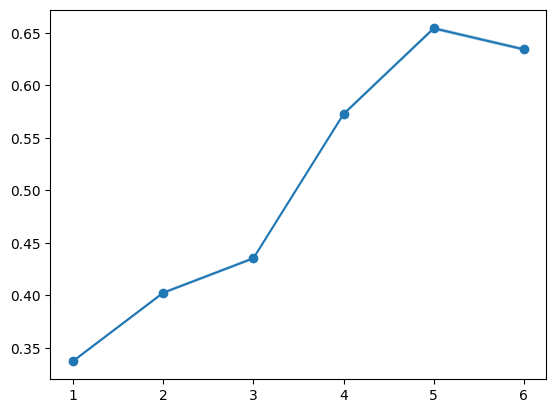

In [22]:
x = np.asarray(range(results.shape[0]))+1
mean = np.mean(results, axis=1)      # shape (k,)
std = np.std(results, axis=1, ddof=1)

n = results.shape[1]
se = std / np.sqrt(n)          # standard error
z = 1.282                      # 80% two-sided normal CI

lower = mean - z * se
upper = mean + z * se

plt.plot(x, mean, label="Mean",marker='o')
plt.fill_between(x, lower, upper, alpha=0.3, label="90% CI")
# plt.legend()
plt.savefig('Marian.pdf',format='pdf')

array([0.00100041, 0.00112545, 0.00116149, 0.0012707 , 0.00136508,
       0.00132832])